In [8]:
#安裝套件
import numpy as np
import matplotlib.pyplot as plt


np.set_printoptions(precision=3,suppress=True)
import pandas as pd
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import scale,StandardScaler
from sklearn.datasets import load_breast_cancer
cancer=load_breast_cancer() #load data

In [10]:
cancer.data.shape #data shape

(569, 30)

In [12]:
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

(569, 30)
(569, 2)


Text(0, 0.5, 'second principle component')

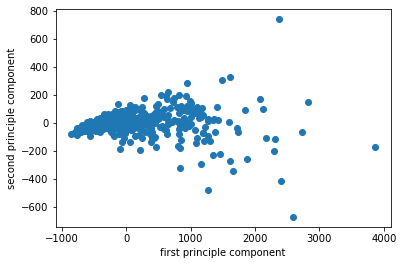

In [14]:
#visulization pca
from sklearn.decomposition import PCA
print(cancer.data.shape)
pca=PCA(n_components=2) #將feature轉成2個主成分
X_pca=pca.fit_transform(cancer.data)
print(X_pca.shape)

plt.scatter(X_pca[:,0],X_pca[:,1]) #觀看散佈圖
plt.xlabel('first principle component')
plt.ylabel('second principle component')

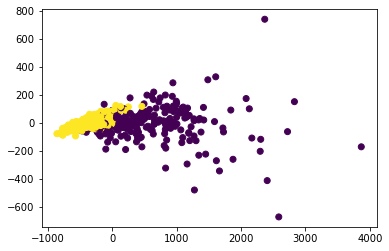

In [15]:
plt.scatter(X_pca[:,0],X_pca[:,1],c=cancer.target) #將target上色，黃色為cancer 決策邊界算明顯 

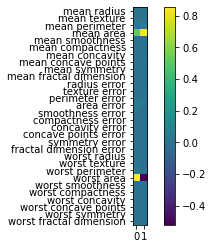

In [18]:
#scaling 標準化前，feature提供的解釋度幾乎都為0
components=pca.components_
plt.imshow(components.T)
plt.yticks(range(len(cancer.feature_names)),cancer.feature_names)
plt.colorbar()
plt.savefig('colorbar.png')

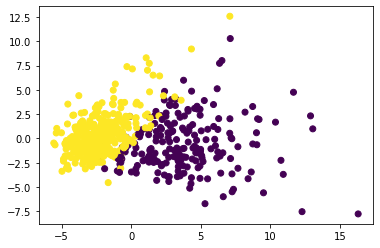

In [21]:
pca_scaled=make_pipeline(StandardScaler(),PCA(n_components=2)) #pipeline first 標準化 在ＰＣＡ
X_pca_scaled=pca_scaled.fit_transform(cancer.data)#fit pipeline
plt.scatter(X_pca_scaled[:,0],X_pca_scaled[:,1],c=cancer.target)#標準化資料更好辨識

In [22]:
pca.components_

array([[ 0.005,  0.002,  0.035,  0.517,  0.   ,  0.   ,  0.   ,  0.   ,
         0.   , -0.   ,  0.   , -0.   ,  0.002,  0.056, -0.   ,  0.   ,
         0.   ,  0.   , -0.   , -0.   ,  0.007,  0.003,  0.049,  0.852,
         0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.009, -0.003,  0.063,  0.852, -0.   , -0.   ,  0.   ,  0.   ,
        -0.   , -0.   , -0.   ,  0.   ,  0.001,  0.008,  0.   ,  0.   ,
         0.   ,  0.   ,  0.   ,  0.   , -0.001, -0.013, -0.   , -0.52 ,
        -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ]])

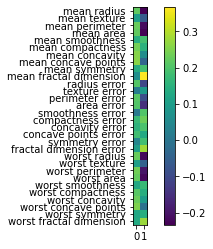

In [24]:
#scaling 標準化後 feature 解釋度上升
components=pca_scaled.named_steps['pca'].components_
plt.imshow(components.T)
plt.yticks(range(len(cancer.feature_names)),cancer.feature_names)
plt.colorbar()
plt.savefig('colorbar.png')

Text(0, 0.5, 'second principle component')

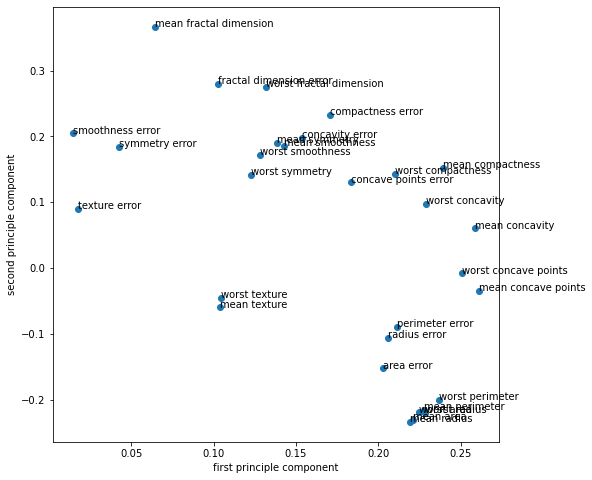

In [25]:
#inspect components
plt.figure(figsize=(8,8))
plt.scatter(components[0],components[1])
for i, feature_contribution in enumerate(components.T):
    plt.annotate(cancer.feature_names[i], feature_contribution)
plt.xlabel('first principle component')
plt.ylabel('second principle component')

In [27]:
#比較沒使用ＰＣＡ的data 和使用後的
from sklearn.linear_model import LogisticRegression
X_train,X_test,y_train,y_test=train_test_split(cancer.data,cancer.target,stratify=cancer.target,test_size=0.3,random_state=0)
lr=LogisticRegression().fit(X_train,y_train)#(監督式學習)
print(lr.score(X_train,y_train))
print(lr.score(X_test,y_test))

0.9623115577889447
0.935672514619883


/Users/lilinghung/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:

pca_lr=make_pipeline(StandardScaler(),PCA(n_components=2),LogisticRegression()) #先pca 後logistic
pca_lr.fit(X_train,y_train)
print(pca_lr.score(X_train,y_train))
print(pca_lr.score(X_test,y_test)) #testing accuracy 下降overfitting

0.9623115577889447
0.9239766081871345


In [29]:
#variance cover
X_train.shape

(398, 30)

In [30]:
#兩主成份
pca.explained_variance_ratio_.shape


(2,)

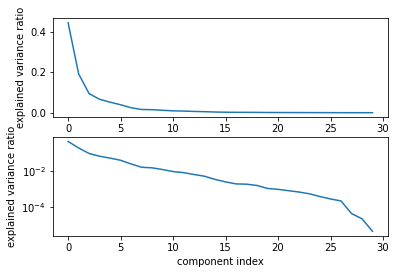

In [32]:
pca_scaled=make_pipeline(StandardScaler(),PCA())
pca_scaled.fit(X_train,y_train)
pca=pca_scaled.named_steps['pca']

fig, axes=plt.subplots(2)
axes[0].plot(pca.explained_variance_ratio_)
axes[1].semilogy(pca.explained_variance_ratio_)
for ax in axes:
    ax.set_xlabel("component index")
    ax.set_ylabel("explained variance ratio")
    
#解釋變異程度，在2個components後 ，可解釋變異度大幅下降